In [1]:
import sys, os
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils import FEATURE_COLS, LABEL_COLS, META_COLS

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)

df = pd.read_csv('../data/raw/ris_dataset.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (50000, 151)


,ue_x,ue_y,ue_z,p_fail_used,n_failed_pixels,pct_failed_pixels,y_real_0,y_real_1,y_real_2,y_real_3,...,pixel_9_0,pixel_9_1,pixel_9_2,pixel_9_3,pixel_9_4,pixel_9_5,pixel_9_6,pixel_9_7,pixel_9_8,pixel_9_9
0,868.866078,347.652950,2.646546,0.282533,37,37.0,-2.032104e-07,-2.113022e-06,-4.524983e-06,-0.000003,...,1,0,0,0,0,0,0,0,0,1
1,906.805759,39.511203,1.595301,0.156052,23,23.0,-6.849037e-08,3.502606e-08,-3.624072e-07,-0.000003,...,0,0,0,1,1,0,0,0,1,0
2,8.265684,168.176799,1.516215,0.237353,23,23.0,2.028959e-06,-3.192117e-06,-7.442286e-07,-0.000003,...,0,0,0,1,0,0,0,0,1,0


In [2]:
print(f'Meta columns    : {len(META_COLS)}   → {META_COLS}')
print(f'Feature columns : {len(FEATURE_COLS)} → first 5: {FEATURE_COLS[:5]}...')
print(f'Label columns   : {len(LABEL_COLS)}  → first 5: {LABEL_COLS[:5]}...')
print()
print('DNN Input  → Feature columns (45)')
print('DNN Output → Label columns   (100 = 10x10 RIS pixels)')

Meta columns    : 6   → ['ue_x', 'ue_y', 'ue_z', 'p_fail_used', 'n_failed_pixels', 'pct_failed_pixels']
Feature columns : 45 → first 5: ['y_real_0', 'y_real_1', 'y_real_2', 'y_real_3', 'y_real_4']...
Label columns   : 100  → first 5: ['pixel_0_0', 'pixel_0_1', 'pixel_0_2', 'pixel_0_3', 'pixel_0_4']...

DNN Input  → Feature columns (45)
DNN Output → Label columns   (100 = 10x10 RIS pixels)


count    50000.000000
mean        25.510320
std         14.763416
min          0.000000
25%         13.000000
50%         25.000000
75%         38.000000
max         66.000000
Name: pct_failed_pixels, dtype: float64


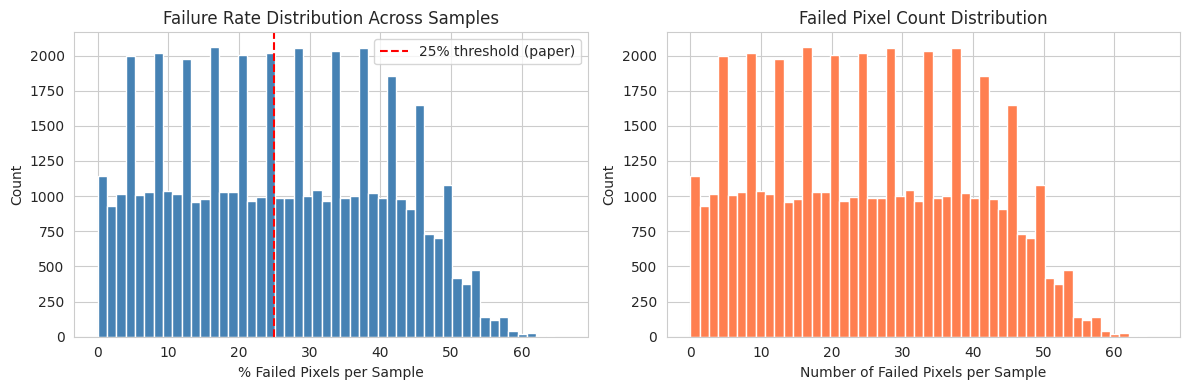


Samples with <= 25% failure: 25,203 (50.4%)


In [3]:
print(df['pct_failed_pixels'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['pct_failed_pixels'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('% Failed Pixels per Sample')
axes[0].set_ylabel('Count')
axes[0].set_title('Failure Rate Distribution Across Samples')
axes[0].axvline(25, color='red', linestyle='--', label='25% threshold (paper)')
axes[0].legend()

axes[1].hist(df['n_failed_pixels'], bins=50, color='coral', edgecolor='white')
axes[1].set_xlabel('Number of Failed Pixels per Sample')
axes[1].set_ylabel('Count')
axes[1].set_title('Failed Pixel Count Distribution')

plt.tight_layout()
plt.show()

print(f"\nSamples with <= 25% failure: {(df['pct_failed_pixels'] <= 25).sum():,} "
      f"({(df['pct_failed_pixels'] <= 25).mean()*100:.1f}%)")

Total pixel observations : 5,000,000
Healthy (0)              : 3,724,484  (74.5%)
Failed  (1)              : 1,275,516  (25.5%)
Imbalance ratio          : 2.92:1

→ pos_weight for BCEWithLogitsLoss = 2.920
  This tells the loss to penalise missed failures more heavily.


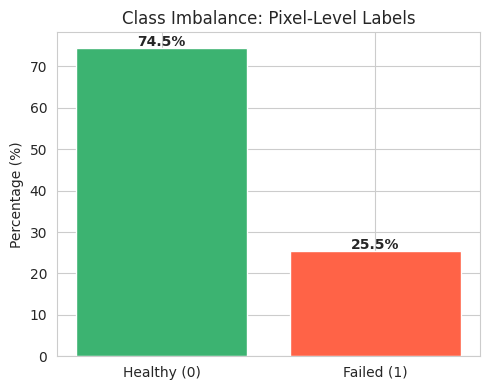

In [4]:
pixel_data = df[LABEL_COLS].values
total      = pixel_data.size
n_failed   = pixel_data.sum()
n_healthy  = total - n_failed

print(f'Total pixel observations : {total:,}')
print(f'Healthy (0)              : {n_healthy:,}  ({n_healthy/total*100:.1f}%)')
print(f'Failed  (1)              : {int(n_failed):,}  ({n_failed/total*100:.1f}%)')
print(f'Imbalance ratio          : {n_healthy/n_failed:.2f}:1')
print()
pos_weight = n_healthy / n_failed
print(f'→ pos_weight for BCEWithLogitsLoss = {pos_weight:.3f}')
print('  This tells the loss to penalise missed failures more heavily.')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Healthy (0)', 'Failed (1)'],
       [n_healthy/total*100, n_failed/total*100],
       color=['mediumseagreen', 'tomato'])
ax.set_ylabel('Percentage (%)')
ax.set_title('Class Imbalance: Pixel-Level Labels')
for i, v in enumerate([n_healthy/total*100, n_failed/total*100]):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

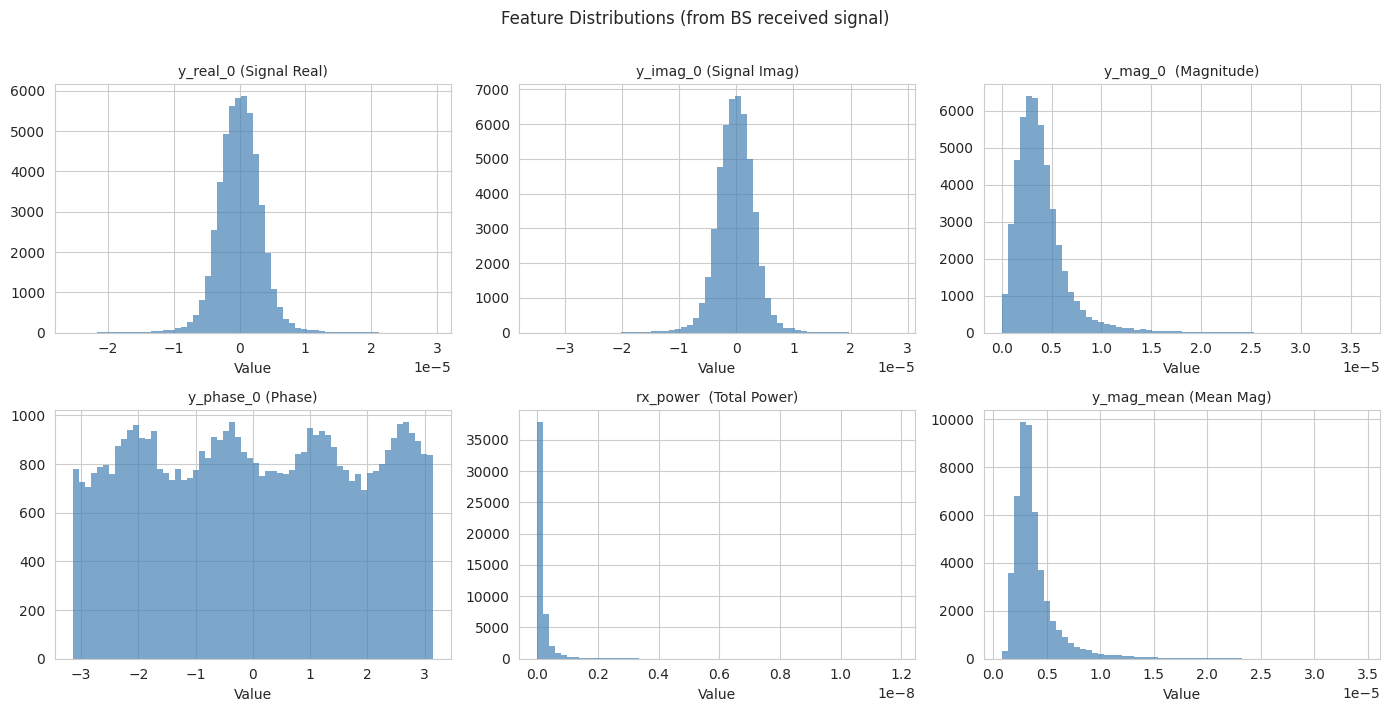

In [5]:
# Show distributions of key feature groups
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
feature_groups = {
    'y_real_0 (Signal Real)' : 'y_real_0',
    'y_imag_0 (Signal Imag)' : 'y_imag_0',
    'y_mag_0  (Magnitude)'   : 'y_mag_0',
    'y_phase_0 (Phase)'      : 'y_phase_0',
    'rx_power  (Total Power)': 'rx_power',
    'y_mag_mean (Mean Mag)'  : 'y_mag_mean',
}
for ax, (title, col) in zip(axes.flat, feature_groups.items()):
    ax.hist(df[col], bins=60, color='steelblue', alpha=0.7, edgecolor='none')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Value')
plt.suptitle('Feature Distributions (from BS received signal)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

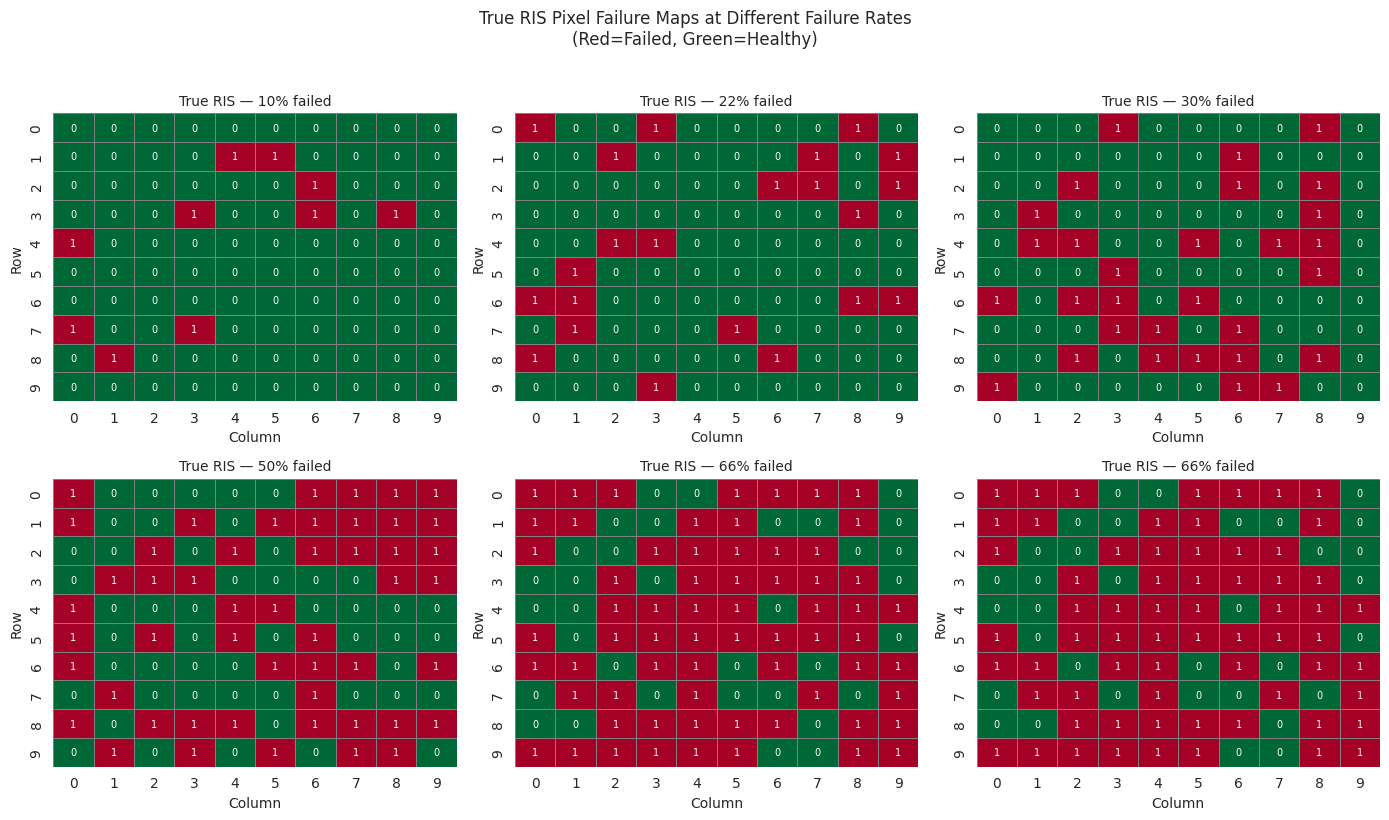

Saved → outputs/plots/eda_ris_grids.png


In [6]:
# Pick 6 samples at different failure rates — mirrors paper Fig.7
target_pcts = [10, 22, 30, 50, 66, 76]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, target in zip(axes.flat, target_pcts):
    idx = (df['pct_failed_pixels'] - target).abs().idxmin()
    row = df.iloc[idx]
    grid = row[LABEL_COLS].values.reshape(10, 10).astype(int)
    actual_pct = row['pct_failed_pixels']

    sns.heatmap(grid, ax=ax, cmap='RdYlGn_r', vmin=0, vmax=1,
                linewidths=0.5, linecolor='gray',
                annot=True, fmt='d', cbar=False,
                annot_kws={'size': 7})
    ax.set_title(f'True RIS — {actual_pct:.0f}% failed', fontsize=10)
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')

plt.suptitle('True RIS Pixel Failure Maps at Different Failure Rates\n'
             '(Red=Failed, Green=Healthy)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/plots/eda_ris_grids.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/plots/eda_ris_grids.png')